O presente trabalho tem como objetivo analisar o comportamento de clientes em um restaurante, com base em dados de consumo e gorjetas, buscando identificar padrões e relações entre as variáveis disponíveis.

A análise visa compreender fatores que podem influenciar o valor das gorjetas, como o valor total da conta, características dos clientes e contexto do atendimento, como dia da semana e período.

Trata-se de um problema de análise exploratória de dados, caracterizado como aprendizado não supervisionado, uma vez que não há uma variável alvo específica a ser prevista.

As principais hipóteses consideradas são:

Existe uma relação positiva entre o valor total da conta e o valor da gorjeta

Fatores como gênero, dia da semana e hábito de fumar podem influenciar o comportamento dos clientes

O padrão de gorjetas tende a ser relativamente consistente entre os clientes

Como restrições, considera-se que os dados são provenientes de uma amostra específica e podem conter valores atípicos (outliers), além de possíveis limitações quanto à representatividade do conjunto de dados.

In [48]:
import pandas as pd

url = "https://raw.githubusercontent.com/gabrielviana7/dados/refs/heads/main/tips.csv"
df = pd.read_csv(url)

df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


O dataset utilizado possui os seguintes atributos:

total_bill: valor total da conta do cliente

tip: valor da gorjeta

sex: gênero do cliente

smoker: indica se o cliente é fumante

day: dia da semana

time: período do atendimento (almoço ou jantar)

size: número de pessoas na mesa

In [49]:
df.shape

(244, 7)

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 244 entries, 0 to 243
Data columns (total 7 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   total_bill  244 non-null    float64
 1   tip         244 non-null    float64
 2   sex         244 non-null    object 
 3   smoker      244 non-null    object 
 4   day         244 non-null    object 
 5   time        244 non-null    object 
 6   size        244 non-null    int64  
dtypes: float64(2), int64(1), object(4)
memory usage: 13.5+ KB


In [51]:
df.describe()

,total_bill,tip,size
count,244.000000,244.000000,244.000000
mean,19.785943,2.998279,2.569672
std,8.902412,1.383638,0.951100
min,3.070000,1.000000,1.000000
25%,13.347500,2.000000,2.000000
50%,17.795000,2.900000,2.000000
75%,24.127500,3.562500,3.000000
max,50.810000,10.000000,6.000000


O dataset possui 244 instâncias e 7 atributos.
Os dados incluem variáveis numéricas, como valor total da conta e gorjeta, e variáveis categóricas, como gênero, dia da semana e período do atendimento.

A análise inicial indica que não há valores nulos.
As variáveis numéricas apresentam variações significativas, especialmente no valor total da conta, o que pode indicar diferentes perfis de consumo.

In [52]:
df.isnull().sum()

,0
total_bill,0
tip,0
sex,0
smoker,0
day,0
time,0
size,0


Não foram identificados valores ausentes no dataset.

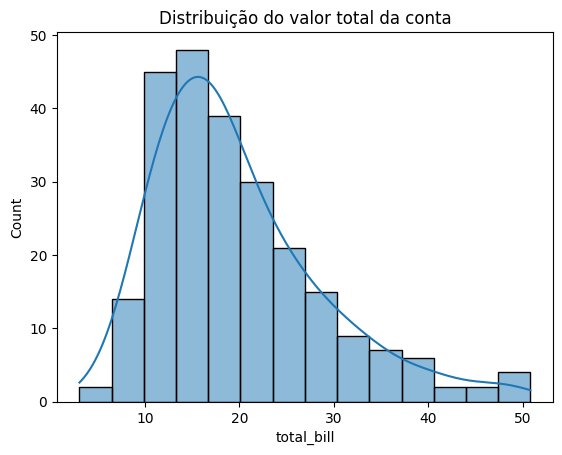

In [53]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.histplot(df['total_bill'], kde=True)
plt.title("Distribuição do valor total da conta")
plt.show()

Observa-se que a distribuição do valor total das contas apresenta concentração em valores mais baixos, com poucos casos de contas mais altas.
Isso indica que a maioria dos clientes possui um padrão de consumo moderado, enquanto poucos apresentam gastos elevados.

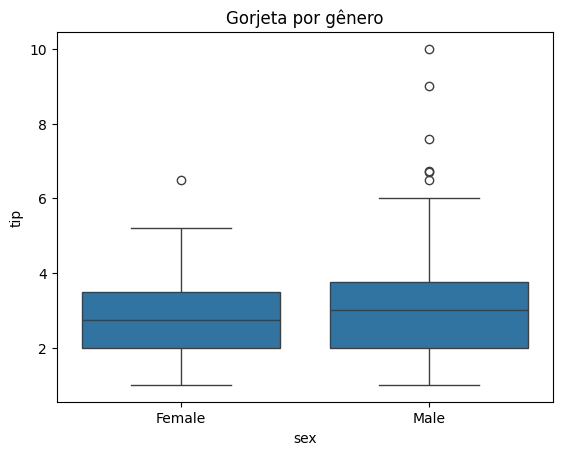

In [54]:
sns.boxplot(x='sex', y='tip', data=df)
plt.title("Gorjeta por gênero")
plt.show()

Observa-se que a distribuição de gorjetas apresenta comportamento semelhante entre os gêneros, embora existam variações individuais.
Não há evidência clara de que o gênero influencie significativamente o valor da gorjeta.

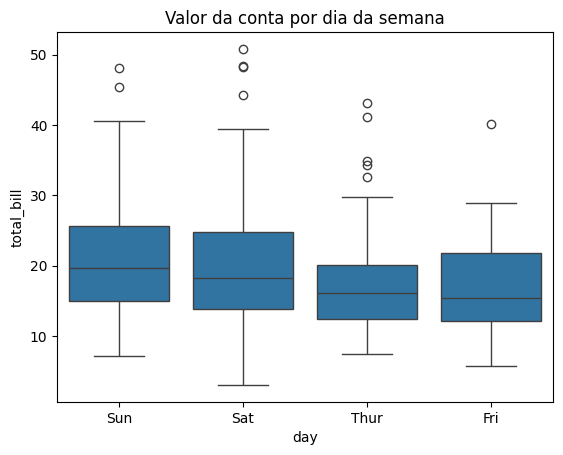

In [55]:
sns.boxplot(x='day', y='total_bill', data=df)
plt.title("Valor da conta por dia da semana")
plt.show()

Nota-se que alguns dias apresentam maior variabilidade no valor das contas, indicando possíveis diferenças no perfil de consumo ao longo da semana.
Isso pode estar relacionado a fatores como fluxo de clientes ou ocasiões específicas.

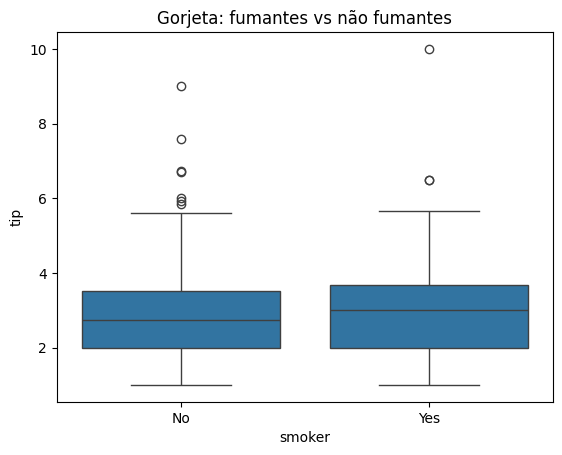

In [56]:
sns.boxplot(x='smoker', y='tip', data=df)
plt.title("Gorjeta: fumantes vs não fumantes")
plt.show()

A comparação entre fumantes e não fumantes indica que não há uma diferença significativa no valor das gorjetas, embora haja variações individuais dentro de cada grupo.

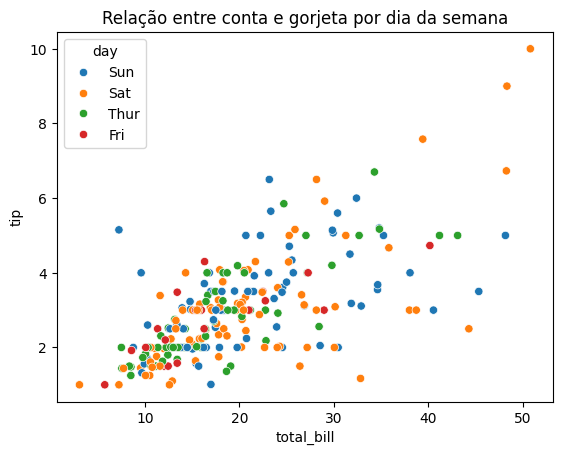

In [57]:
sns.scatterplot(x='total_bill', y='tip', hue='day', data=df)
plt.title("Relação entre conta e gorjeta por dia da semana")
plt.show()

A análise combinada mostra que a relação entre o valor da conta e a gorjeta se mantém consistente independentemente do dia da semana, reforçando a hipótese de comportamento proporcional dos clientes.

In [58]:
df['porcentagem_gorjeta'] = df['tip'] / df['total_bill']

Foi criada uma nova variável representando a porcentagem da gorjeta em relação ao valor total da conta, com o objetivo de analisar o comportamento proporcional dos clientes ao conceder gorjetas.

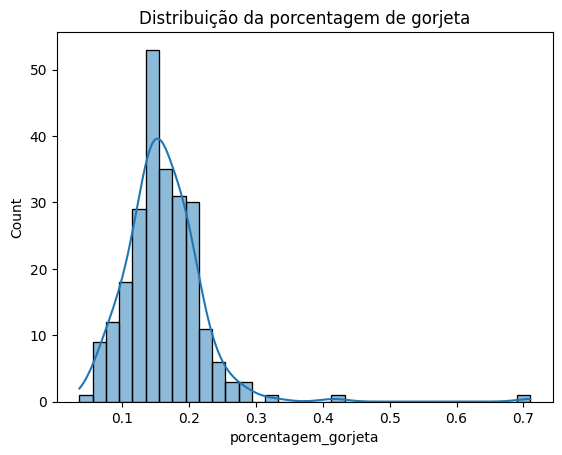

In [59]:
sns.histplot(df['porcentagem_gorjeta'], kde=True)
plt.title("Distribuição da porcentagem de gorjeta")
plt.show()

In [60]:
df.mode()

,total_bill,tip,sex,smoker,day,time,size,porcentagem_gorjeta
0,13.42,2.0,Male,No,Sat,Dinner,2.0,0.144823
1,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.153846


A análise da moda permite identificar os valores mais frequentes no dataset, contribuindo para uma melhor compreensão do comportamento dos dados.

A distribuição da porcentagem de gorjeta indica que a maioria dos clientes segue um padrão relativamente consistente, com pequenas variações.
No entanto, existem alguns casos extremos que podem representar comportamentos atípicos.

In [61]:
df_encoded = pd.get_dummies(df, drop_first=True)
df_encoded.head()

,total_bill,tip,size,porcentagem_gorjeta,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,16.99,1.01,2,0.059447,False,False,False,True,False,False
1,10.34,1.66,3,0.160542,True,False,False,True,False,False
2,21.01,3.50,3,0.166587,True,False,False,True,False,False
3,23.68,3.31,2,0.139780,True,False,False,True,False,False
4,24.59,3.61,4,0.146808,False,False,False,True,False,False


Foi aplicada a técnica de one-hot encoding para transformar variáveis categóricas em variáveis numéricas, permitindo sua utilização em etapas futuras de modelagem.

In [62]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

colunas_numericas = ['total_bill', 'tip', 'size', 'porcentagem_gorjeta']

df_encoded[colunas_numericas] = scaler.fit_transform(df_encoded[colunas_numericas])

df_encoded.head()

,total_bill,tip,size,porcentagem_gorjeta,sex_Male,smoker_Yes,day_Sat,day_Sun,day_Thur,time_Lunch
0,-0.314711,-1.439947,-0.600193,-1.663018,False,False,False,True,False,False
1,-1.063235,-0.969205,0.453383,-0.004282,True,False,False,True,False,False
2,0.137780,0.363356,0.453383,0.094915,True,False,False,True,False,False
3,0.438315,0.225754,-0.600193,-0.344926,True,False,False,True,False,False
4,0.540745,0.443020,1.506958,-0.229625,False,False,False,True,False,False


Foi realizada a padronização das variáveis numéricas utilizando a técnica StandardScaler, com o objetivo de colocar os dados na mesma escala e evitar que variáveis com maior magnitude influenciem desproporcionalmente análises futuras.

In [63]:
df.describe()
df_encoded.describe()

,total_bill,tip,size,porcentagem_gorjeta
count,2.440000e+02,2.440000e+02,2.440000e+02,2.440000e+02
mean,-7.871663e-17,2.839259e-16,-5.824121e-17,-5.414612e-17
std,1.002056e+00,1.002056e+00,1.002056e+00,1.002056e+00
min,-1.881547e+00,-1.447189e+00,-1.653768e+00,-2.053663e+00
25%,-7.247111e-01,-7.229713e-01,-6.001926e-01,-5.197181e-01
50%,-2.241005e-01,-7.117518e-02,-6.001926e-01,-9.898465e-02
75%,4.886857e-01,4.086192e-01,4.533829e-01,5.032724e-01
max,3.492068e+00,5.070772e+00,3.614110e+00,9.016734e+00


Após a padronização, observa-se que as variáveis numéricas passaram a apresentar média próxima de zero e desvio padrão próximo de um, conforme esperado.

Conclusão

A análise exploratória dos dados permitiu identificar padrões relevantes no comportamento dos clientes.
Observou-se que o valor da gorjeta está diretamente relacionado ao valor total da conta, indicando um comportamento proporcional.

As análises por categoria (gênero, dia da semana e hábito de fumar) não evidenciaram diferenças significativas no valor das gorjetas, embora existam variações individuais.

A criação da variável de porcentagem de gorjeta possibilitou uma análise mais aprofundada do comportamento dos clientes, revelando certa consistência na proporção aplicada.

As etapas de pré-processamento, incluindo encoding e padronização, prepararam os dados para possíveis análises futuras ou aplicação de modelos de machine learning.

De forma geral, o trabalho permitiu compreender melhor os padrões de consumo e identificar possíveis pontos de atenção para análises mais avançadas.

Qual é a descrição do problema?
Analisar o comportamento de clientes em um restaurante, buscando identificar padrões de consumo e fatores que influenciam o valor das gorjetas.

Este é um problema supervisionado ou não supervisionado?
Trata-se de um problema de análise exploratória de dados, caracterizado como não supervisionado.

Quais são as hipóteses?
Espera-se que o valor da gorjeta aumente conforme o valor da conta, e que fatores como dia da semana, gênero e hábito de fumar possam influenciar esse comportamento.

Quais restrições foram consideradas?
Foi utilizado um dataset público, assumindo que os dados representam corretamente o comportamento dos clientes, podendo conter outliers.

Há valores faltantes?
Não foram identificados valores ausentes no dataset.

Principais insights:

Existe relação positiva entre valor da conta e gorjeta
O comportamento de gorjeta é relativamente consistente
Variáveis categóricas apresentam baixa influência significativa